In [1]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# pandas display options
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

random_state = 42
np.random.seed(random_state)

base_path = 'xai'
os.makedirs(base_path, exist_ok=True)
figures_path = os.path.join(base_path, 'figures')
os.makedirs(figures_path, exist_ok=True)
data_path = 'data'
file_name = 'season.csv'
years = range(2019, 2023)

In [2]:
from f1pitpred.loading import load_from_csv
data = load_from_csv(years, data_path, file_name)

# Preprocessing

In [3]:
from f1pitpred.preprocessing import get_preprocessed_train_test_split
df = data.copy()
train, test, encoder, train_groups, test_groups = get_preprocessed_train_test_split(
    df, 
    0.2, 
    return_groups=True, 
    random_state=random_state
)

In [4]:
from f1pitpred.preprocessing import get_x_y_pit
X_train, y_train = get_x_y_pit(train)
X_test, y_test = get_x_y_pit(test)

# Modelisation

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
def specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp)

def balanced_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)
    return (specificity + sensitivity) / 2

In [6]:
model = RandomForestClassifier(
    n_estimators=2000,
    max_depth=5, 
    max_features='sqrt',
    criterion='entropy',
    class_weight='balanced_subsample',
    random_state=random_state,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', criterion='entropy',
                       max_depth=5, n_estimators=2000, n_jobs=-1,
                       random_state=42)

In [7]:
y_pred = model.predict(X_test)

print("Balanced accuracy : ", balanced_accuracy(y_test, y_pred))
print("Specificity : ", specificity(y_test, y_pred))

Balanced accuracy :  0.7359829358594803
Specificity :  0.7464223934580909


In [8]:
from sklearn.metrics import classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[9493 3225]
 [ 101  267]]
              precision    recall  f1-score   support

       False       0.99      0.75      0.85     12718
        True       0.08      0.73      0.14       368

    accuracy                           0.75     13086
   macro avg       0.53      0.74      0.49     13086
weighted avg       0.96      0.75      0.83     13086



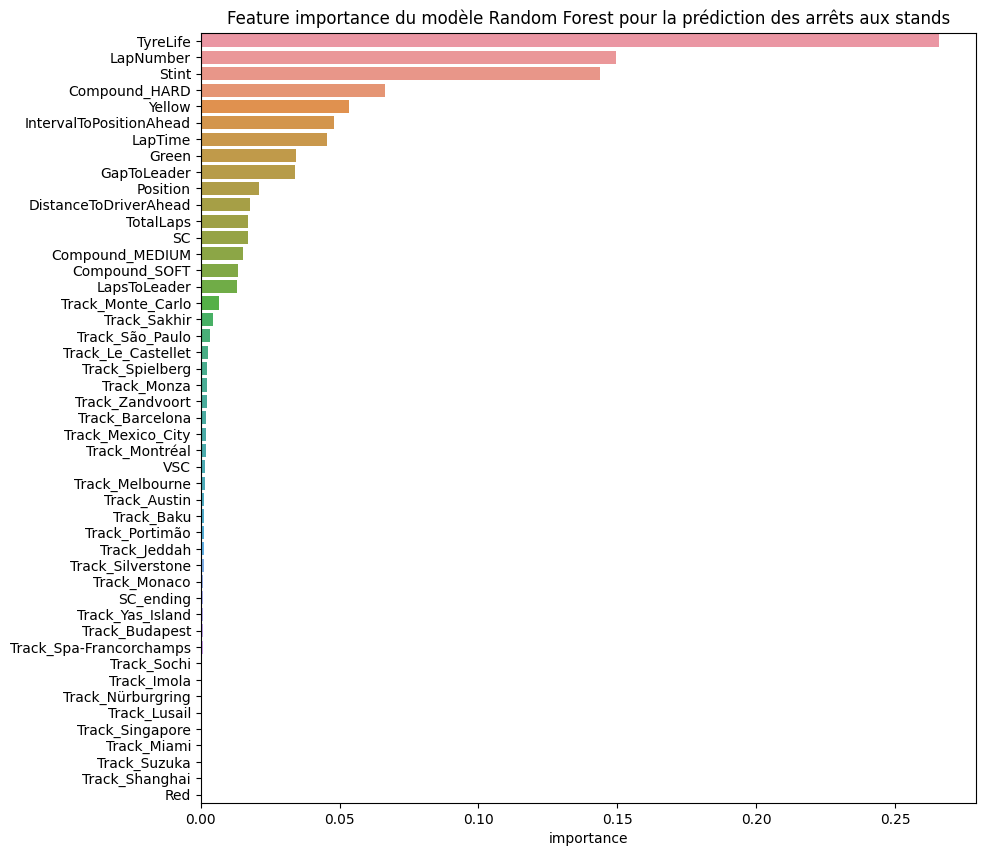

In [9]:
import seaborn as sns

def plot_feature_importance(model, X_train, save_path=None):
    feature_importances = pd.DataFrame(
        model.feature_importances_,
        index = X_train.columns,
        columns=['importance']
    ).sort_values('importance', ascending=False)
    plt.figure(figsize=(10, 10))
    sns.barplot(
        x='importance',
        y=feature_importances.index,
        data=feature_importances,
        orient='h'
    )
    plt.title('Feature importance du modèle Random Forest pour la prédiction des arrêts aux stands')
    if save_path is not None:
        plt.savefig(save_path, format='svg')
    plt.show()

plot_feature_importance(model, X_train, save_path=os.path.join(figures_path, 'feature_importance_rf_pit.svg'))

In [17]:
# Save model
import pickle
models_dir = 'models/Random_Forest'
os.makedirs(models_dir, exist_ok=True)
pickle.dump(model, open(models_dir + '/model.pkl', 'wb'))
pickle.dump(encoder, open(models_dir + '/encoder.pkl', 'wb'))

In [8]:
import pickle
models_dir = 'models/Random_Forest'
model = pickle.load(open(models_dir + '/model.pkl', 'rb'))
encoder = pickle.load(open(models_dir + '/encoder.pkl', 'rb'))

In [34]:
from lime import lime_tabular

explainer = lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    class_names=['No Pit', 'Pit'],
    mode='classification',
    discretize_continuous=True,
    random_state=random_state
)

In [9]:
#import pickle
#encoder_path = os.path.join("models", "f1_score", "encoder.pkl")
#encoder = pickle.load(open(encoder_path, 'rb'))

validation_races = load_from_csv([2023], data_path, file_name)

In [49]:
from f1pitpred.preprocessing import preprocess_new_data
race = validation_races.query('DriverNumber == "55" and Track == "Miami"').reset_index(drop=True)
race_preprocessed = preprocess_new_data(race, encoder)

<Axes: title={'center': 'Baku 2023 - Sergio Perez'}, xlabel='Lap Number', ylabel='Probability of pitting'>

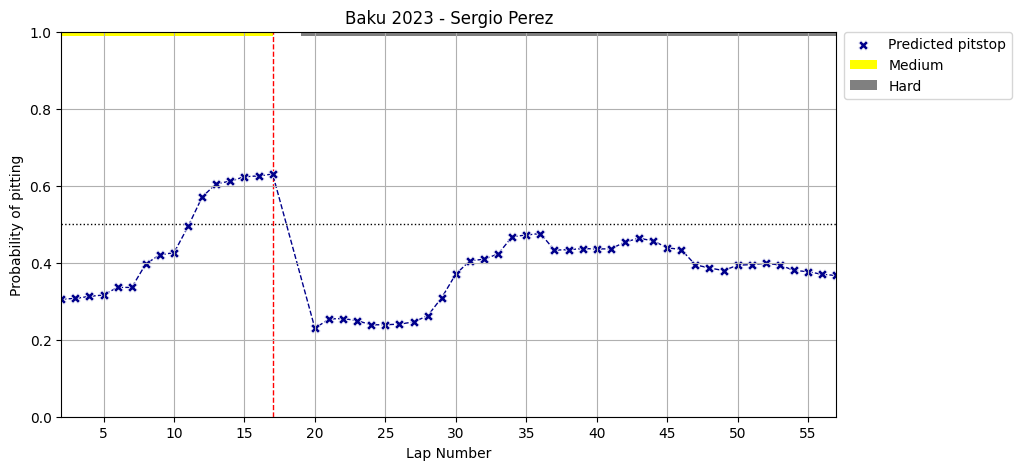

In [51]:
from f1pitpred.preprocessing import get_x_y_pit

X_race, y_race = get_x_y_pit(race_preprocessed)

proba = model.predict_proba(X_race)[:, 1]

from f1pitpred.plotting import plot_race_predictions, plot_stoppages, plot_tyres

_, ax = plt.subplots(figsize=(10, 5))
ax.grid(True)
plot_race_predictions(X_race, y_race, proba, ax, title=f'Baku 2023 - Sergio Perez', color='darkblue')
plot_stoppages(X_race, ax)
plot_tyres(X_race, ax)

#plt.savefig(os.path.join(figures_path, 'baku_2023_sergio_perez.svg'), format='svg')

In [52]:
x_2 = race_preprocessed.query('LapNumber == 8').drop(['is_pitting'], axis=1).iloc[0]
x_13 = race_preprocessed.query('LapNumber == 49').drop(['is_pitting'], axis=1).iloc[0]
x_28 = race_preprocessed.query('LapNumber == 16').drop(['is_pitting'], axis=1).iloc[0]

In [48]:
model.predict_proba(x_2.values.reshape(1, -1))

c:\Users\Nelson Jeanrenaud\miniconda3\envs\bsc\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[0.41790367, 0.58209633]])

c:\Users\Nelson Jeanrenaud\miniconda3\envs\bsc\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


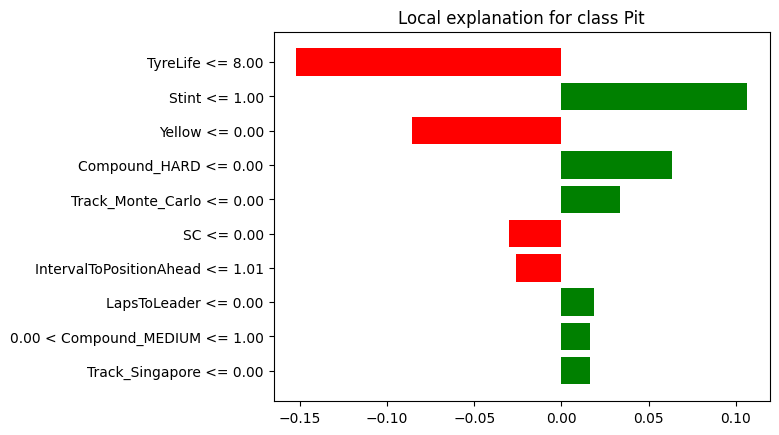

In [53]:
exp = explainer.explain_instance(
        x_2,
        model.predict_proba,
        num_features=10,
    )

exp.as_pyplot_figure()
plt.savefig(os.path.join(figures_path, 'explanation_miami_8.svg'), bbox_inches='tight', format='svg')

c:\Users\Nelson Jeanrenaud\miniconda3\envs\bsc\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


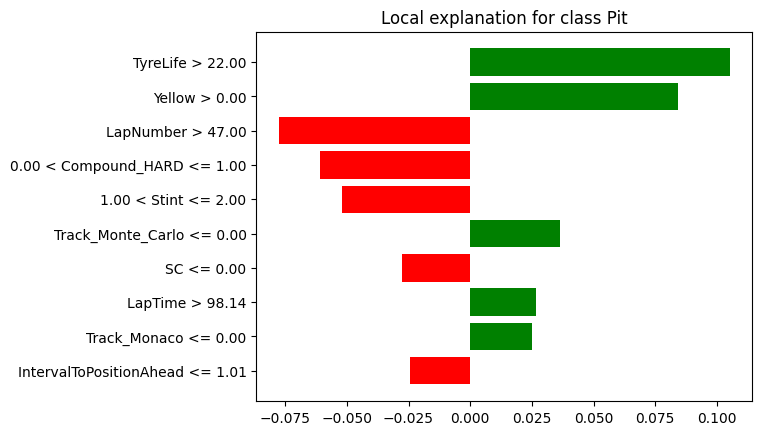

In [43]:
exp = explainer.explain_instance(
        x_13,
        model.predict_proba,
        num_features=10,
    )

#exp.show_in_notebook(show_table=True)
#exp.save_to_file(f'explanation_barcelona_verstappen_13.html')
exp.as_pyplot_figure()
plt.savefig(os.path.join(figures_path, 'explanation_baku_49.svg'), bbox_inches='tight', format='svg')

c:\Users\Nelson Jeanrenaud\miniconda3\envs\bsc\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


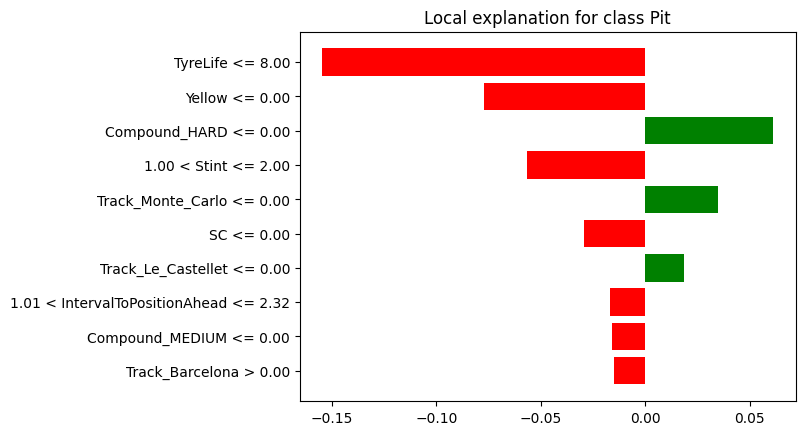

In [37]:
exp = explainer.explain_instance(
        x_28,
        model.predict_proba,
        num_features=10,
    )

#exp.show_in_notebook(show_table=True)
#exp.save_to_file(f'explanation_barcelona_verstappen_27.html')
exp.as_pyplot_figure()
plt.savefig(os.path.join(figures_path, 'explanation_barcelona_stroll_16.svg'), bbox_inches='tight', format='svg')

In [23]:
from f1pitpred.plotting import plot_race_predictions, plot_stoppages, plot_tyres
def explain_race(race_id):
    race = list(test_groups.keys())[race_id]

    driver_number = race[2]
    track = race[1]
    year = race[0]

    test_race_x = X_test.iloc[test_groups.get(race)].reset_index(drop=True)
    test_race_x['index'] = test_race_x['LapNumber']
    test_race_x.set_index('index', inplace=True)
    test_race_y = y_test.iloc[test_groups.get(race)].reset_index(drop=True)
    test_race_y.index = test_race_x.index
    probabilities = model.predict_proba(test_race_x)[::,1]

    _, ax = plt.subplots(figsize=(15, 5))
    ax.grid(True)
    plot_race_predictions(test_race_x, test_race_y, probabilities, ax, title=f'Race {track} {year} of driver {driver_number}')
    plot_stoppages(test_race_x, ax)
    plot_tyres(test_race_x, ax)

    #plt.savefig(f'{figures_path}/preds_{race_id}.png', bbox_inches='tight')
    plt.show()

    #pit_id = np.where(test_race_y == 1)[0][0]
    #print(type(test_race_x.iloc[pit_id]))
    #exp = explainer.explain_instance(
    #    test_race_x.iloc[pit_id],
    #    model.predict_proba,
    #    num_features=10,
    #    top_labels=1
    #)
#
    #exp.show_in_notebook(show_table=True)
    #exp.save_to_file(f'{figures_path}/explanation_{race_id}.html')